In [48]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, operator
from pydantic import Field, BaseModel
from dotenv import load_dotenv
import json
load_dotenv()

True

In [ ]:
# Create workflow which analyze essay based on clarity of thoughts, Depth of analysis, language understanding and give evaluation score and feedback

# Output Schema
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Feedback of an essay")
    score: int = Field(description="Score based on analysis", ge=0, le=10)

In [36]:
# State 
class State(TypedDict):
    essay: str
    doa: str
    lang: str
    cot: str
    
    individual_score: Annotated[list[str], operator.add]
    avg_score: float
    overall_feedback: str

In [29]:
llm = ChatOpenAI(model='gpt-4o-mini')
structured_model = llm.with_structured_output(EvaluationSchema, include_raw=False)

In [40]:
def evaluate_cot(state: State):
    prompt= f"Evaluate given essay based on user's clarity of thoughts: {state['essay']}"
    out = structured_model.invoke(prompt)
    
    return {"cot":out.feedback, "individual_score":[out.score]}

def evaluate_doa(state: State):
    prompt= f"Evaluate given essay based on Depth of analysis: {state['essay']}"
    out = structured_model.invoke(prompt)
    
    return {"doa":out.feedback, "individual_score":[out.score]}

def evaluate_lang(state: State):
    prompt= f"Evaluate given essay based on Language used: {state['essay']}"
    out = structured_model.invoke(prompt)
    
    return {"lang":out.feedback, "individual_score":[out.score]}

def summery(state: State):
    prompt = f"based on following evaluation generate essay overall feedback. Use next params: cot={state['cot']}, doa={state['doa']} and language: {state['lang']}"
    
    res = llm.invoke(prompt).content
    
    return {"overall_feedback":res, "avg_score":sum(state['individual_score'])/len(state['individual_score'])}


In [41]:
# define graph
graph  = StateGraph(State)

# add Nodes
graph.add_node("evaluate_cot", evaluate_cot)
graph.add_node("evaluate_doa", evaluate_doa)
graph.add_node("evaluate_lang", evaluate_lang)
graph.add_node("summery", summery)

# add Edges
graph.add_edge(START, "evaluate_cot")
graph.add_edge(START, "evaluate_doa")
graph.add_edge(START, "evaluate_lang")

graph.add_edge("evaluate_cot", "summery")
graph.add_edge("evaluate_doa", "summery")
graph.add_edge("evaluate_lang", "summery")

graph.add_edge("summery", END)

# compile
workflow = graph.compile()

In [ ]:
#invoke
essay = '''
    Hey Mike, I need a Godfather Sub, no tomato, and a Foot Surfer without avocado! The biggest hit of the day approaches as the clock ticks down to 12:00 noon. I rush over the order tickets. The bell chimes, the door swings open, and the guys working construction on the Jupiter Medical Center flood the del
'''
updated_state = workflow.invoke({"essay":essay})

d:\Projects\python\agentic-ai-langGraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback...ed narrative.", score=5), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
d:\Projects\python\agentic-ai-langGraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback... readability.", score=5), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
d:\Projects\python\agentic-ai-langGraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be 

In [51]:
print(updated_state)

{'essay': '\n    Hey Mike, I need a Godfather Sub, no tomato, and a Foot Surfer without avocado! The biggest hit of the day approaches as the clock ticks down to 12:00 noon. I rush over the order tickets. The bell chimes, the door swings open, and the guys working construction on the Jupiter Medical Center flood the del\n', 'doa': "The essay captures a moment in time with engaging imagery and a hint of urgency, but it lacks depth in its analysis. While it paints a vivid scene at a deli during lunchtime, it doesn't delve into any thematic or emotional layers that might give more insight into the characters or setting. The focus remains on the immediate actions without exploring motivations, social dynamics, or the significance of the setting itself, which would have added depth. A deeper exploration of the environment or the characters' backgrounds could enhance engagement and provide a more layered narrative.", 'lang': "The language used in this essay is informal and conversational, wh

In [ ]:
# Testing structured Model
prompt=f"You are essay evaluator. Evaluate Essay and give score in range of 0-10. 0 means bad and 10 means best. use next essay content: {essay}"

structured_model.invoke(prompt)

d:\Projects\python\agentic-ai-langGraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback...descriptions.', score=4), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(


EvaluationSchema(feedback='The essay begins with a casual and engaging tone, depicting a scene from a lunch rush at a food establishment. The dialogue adds a personal touch, making it relatable. However, the essay ends abruptly, lacking a clear conclusion or further development of ideas. It creates an interesting start but does not fully explore the setting or the characters involved. For improvement, it should include more detail about the scene, character interactions, or the emotions involved in the order process. The writing style is informal and might benefit from more structured thoughts and descriptions.', score=4)

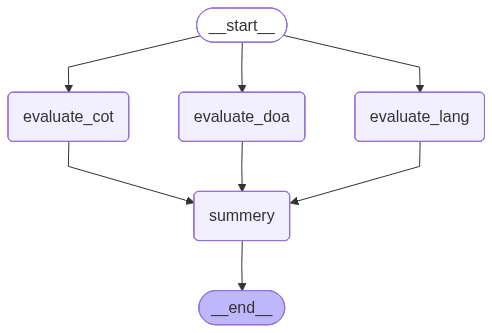

In [46]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())